In [1]:
import pandas as pd
import numpy as np
import nltk
import string
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import warnings 
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from scipy.sparse import csr_matrix, hstack
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print("Imports done.")

Imports done.


[nltk_data] Downloading package stopwords to /home/Aditya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/Aditya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/Aditya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/Aditya/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /home/Aditya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/Aditya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
liar_cols = ['id','label','statement','subject','speaker','job',
             'state','party','barely_true_ct','false_ct',
             'half_true_ct','mostly_true_ct','pants_on_fire_ct','venue']

liar_train = pd.read_csv('../data/liar/train.tsv', sep='\t', header=None, names=liar_cols)
liar_val   = pd.read_csv('../data/liar/valid.tsv', sep='\t', header=None, names=liar_cols)
liar_test  = pd.read_csv('../data/liar/test.tsv',  sep='\t', header=None, names=liar_cols)

liar_df = pd.concat([liar_train, liar_val, liar_test], ignore_index=True)

print("LIAR loaded:", liar_df.shape)

LIAR loaded: (12791, 14)


In [3]:
fake_labels = {'pants-fire', 'false', 'barely-true'}
real_labels = {'half-true', 'mostly-true', 'true'}

liar_df = liar_df[liar_df['label'].isin(fake_labels | real_labels)].copy()

liar_df['label'] = liar_df['label'].apply(
    lambda x: 1 if x in fake_labels else 0
)

print("After filtering:", liar_df.shape)

After filtering: (12791, 14)


In [4]:
liar_df['title'] = liar_df['statement']
liar_df['text']  = liar_df['statement']

liar_df = liar_df[['title', 'text', 'subject', 'label']]

In [5]:
kaggle_df = pd.read_csv('../data/kaggle_only.csv')

print("Kaggle loaded:", kaggle_df.shape)

Kaggle loaded: (44898, 11)


In [6]:
kaggle_df['source'] = 'kaggle'
liar_df['source']   = 'liar'

combined_df = pd.concat([kaggle_df, liar_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined shape:", combined_df.shape)
print(combined_df['source'].value_counts())

Combined shape: (57689, 12)
source
kaggle    44898
liar      12791
Name: count, dtype: int64


In [7]:
import re
import string

def sensationalism_features(text):
    text = str(text)
    words = text.split()
    return pd.Series({
        'exclamation_count': text.count('!'),
        'question_count':    text.count('?'),
        'caps_ratio':        sum(1 for w in words if w.isupper() and len(w) > 2)
                             / max(len(words), 1),
        'punct_ratio':       sum(1 for c in text if c in string.punctuation)
                             / (len(text) + 1),
        'repeated_punct':    len(re.findall(r'([!?])\1+', text)),
        'text_length':       len(text),
        'word_count':        len(words)
    })

combined_df[['exclamation_count', 'question_count', 'caps_ratio',
             'punct_ratio', 'repeated_punct', 'text_length', 'word_count']] = \
    combined_df['text'].apply(sensationalism_features)

print("Sensationalism features added to ALL rows.")
print(combined_df[['exclamation_count','question_count',
                   'caps_ratio','punct_ratio','text_length','word_count']].isnull().sum())
print("\nDataset counts:")
print(combined_df['source'].value_counts())
print("\nFake/Real per source:")
print(pd.crosstab(combined_df['source'], combined_df['label']))

Sensationalism features added to ALL rows.
exclamation_count    0
question_count       0
caps_ratio           0
punct_ratio          0
text_length          0
word_count           0
dtype: int64

Dataset counts:
source
kaggle    44898
liar      12791
Name: count, dtype: int64

Fake/Real per source:
label       0      1
source              
kaggle  21417  23481
liar     7134   5657


        exclamation_count  question_count  caps_ratio  punct_ratio
source                                                            
kaggle             0.4076          0.6786      0.0167       0.0229
liar               0.0067          0.0076      0.0070       0.0267


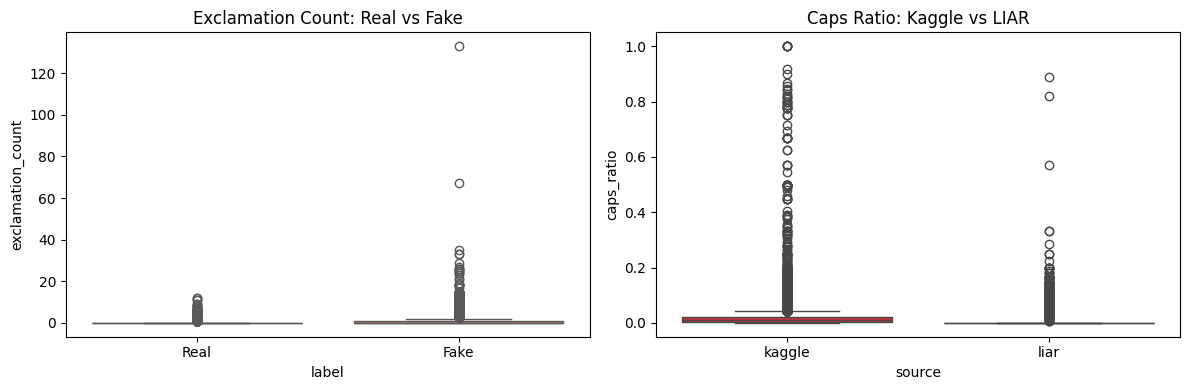

In [8]:
# ── Verify sensationalism features across both sources ──
print(combined_df.groupby('source')[
    ['exclamation_count', 'question_count', 'caps_ratio', 'punct_ratio']
].mean().round(4))

# Visual check
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='label', y='exclamation_count', data=combined_df,
            palette='Set2', ax=axes[0])
axes[0].set_xticklabels(['Real', 'Fake'])
axes[0].set_title('Exclamation Count: Real vs Fake')

sns.boxplot(x='source', y='caps_ratio', data=combined_df,
            palette='Set1', ax=axes[1])
axes[1].set_title('Caps Ratio: Kaggle vs LIAR')

plt.tight_layout()
plt.show()

=== Average Sensationalism: Fake vs Real ===

       exclamation_count  question_count  caps_ratio  punct_ratio  repeated_punct
label                                                                            
Real              0.0476          0.0773      0.0141       0.0232          0.0005
Fake              0.5845          0.9732      0.0149       0.0242          0.0346


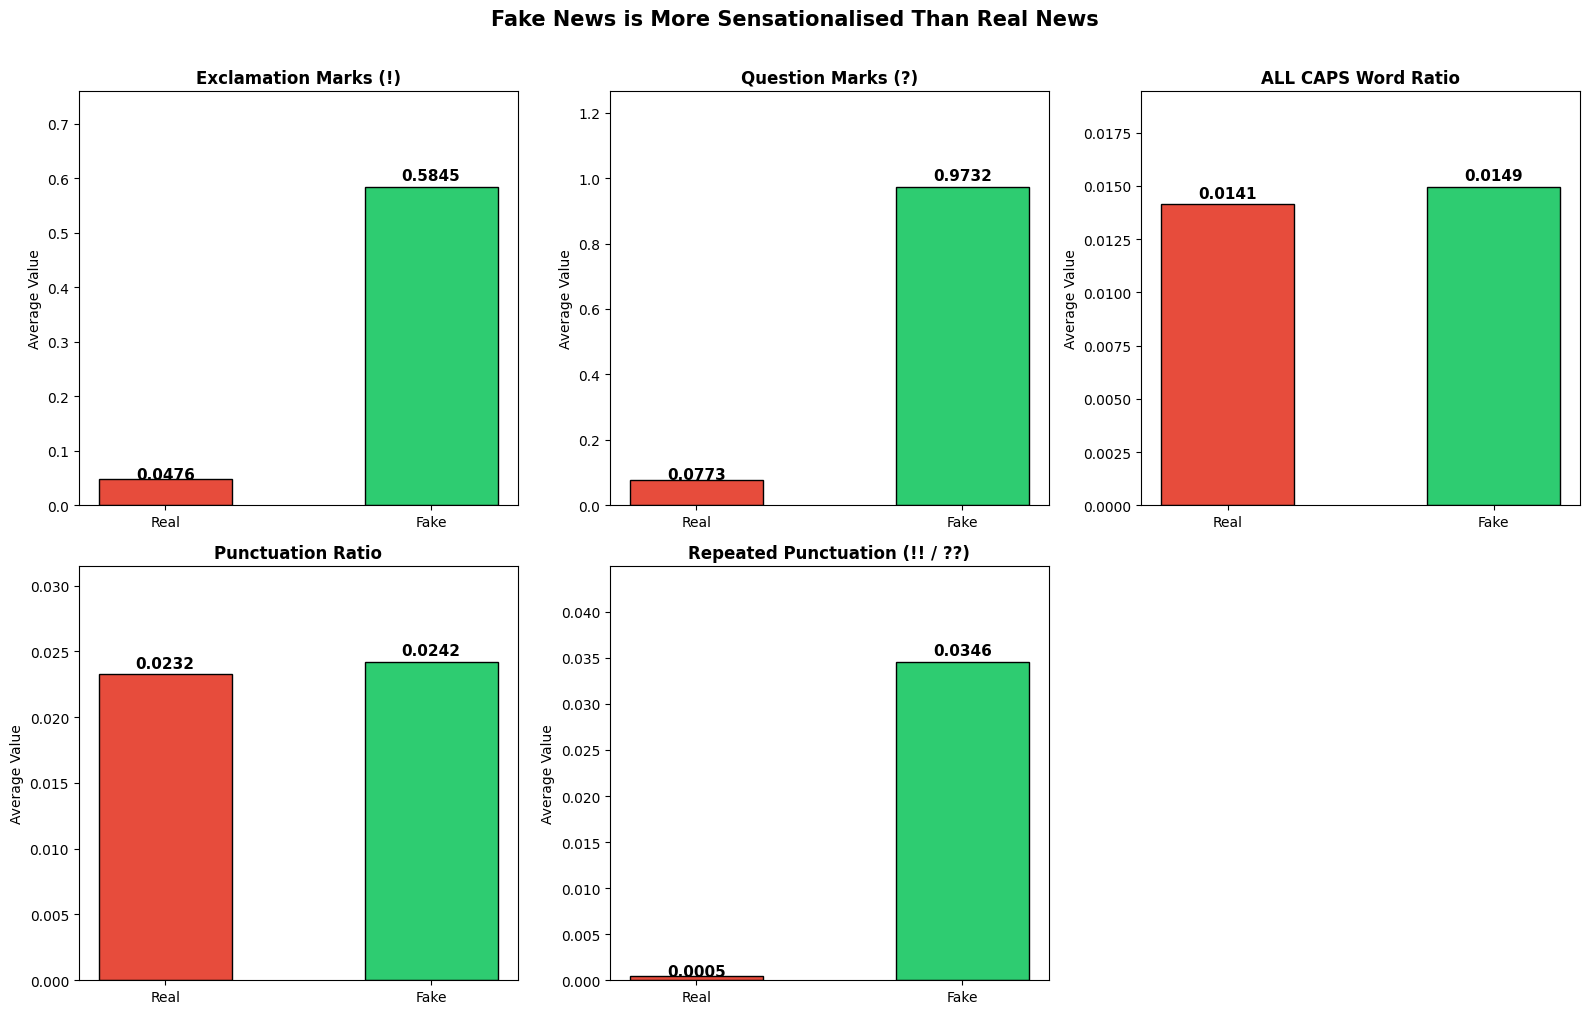


=== Statistical Significance (Mann-Whitney U Test) ===

exclamation_count      | p = 0.0000 | ✓ SIGNIFICANT
question_count         | p = 0.0000 | ✓ SIGNIFICANT
caps_ratio             | p = 1.0000 | ✗ not significant
punct_ratio            | p = 0.3168 | ✗ not significant
repeated_punct         | p = 0.0000 | ✓ SIGNIFICANT


In [9]:
# ── Sensationalism Evidence: Fake vs Real ──
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Average Sensationalism: Fake vs Real ===\n")
print(combined_df.groupby('label')[
    ['exclamation_count', 'question_count', 'caps_ratio', 'punct_ratio', 'repeated_punct']
].mean().round(4).rename(index={0: 'Real', 1: 'Fake'}).to_string())

# ── Visualization ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = [
    ('exclamation_count', 'Exclamation Marks (!)'),
    ('question_count',    'Question Marks (?)'),
    ('caps_ratio',        'ALL CAPS Word Ratio'),
    ('punct_ratio',       'Punctuation Ratio'),
    ('repeated_punct',    'Repeated Punctuation (!! / ??)'),
]

colors = ['#e74c3c', '#2ecc71']   # red = fake, green = real

for ax, (col, title) in zip(axes, features):
    means = combined_df.groupby('label')[col].mean()
    bars  = ax.bar(['Real', 'Fake'], [means[0], means[1]], color=colors, width=0.5, edgecolor='black')
    for bar, val in zip(bars, [means[0], means[1]]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + bar.get_height() * 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Value')
    ax.set_ylim(0, max(means[0], means[1]) * 1.3)

# hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Fake News is More Sensationalised Than Real News',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/sensationalism_evidence.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical confirmation ──
from scipy.stats import mannwhitneyu

print("\n=== Statistical Significance (Mann-Whitney U Test) ===\n")
for col in ['exclamation_count', 'question_count', 'caps_ratio', 'punct_ratio', 'repeated_punct']:
    fake_vals = combined_df[combined_df['label'] == 1][col].dropna()
    real_vals = combined_df[combined_df['label'] == 0][col].dropna()
    stat, p = mannwhitneyu(fake_vals, real_vals, alternative='greater')
    sig = "✓ SIGNIFICANT" if p < 0.05 else "✗ not significant"
    print(f"{col:<22} | p = {p:.4f} | {sig}")

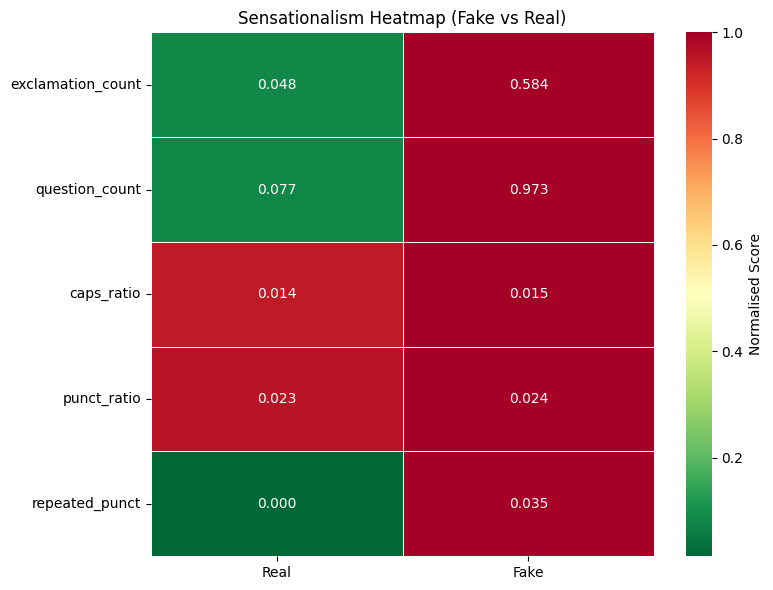

Chart saved → ../data/sensationalism_heatmap.png


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure label is consistent
combined_df['label'] = combined_df['label'].astype(int)

plt.figure(figsize=(8, 6))

sens_cols = [
    'exclamation_count',
    'question_count',
    'caps_ratio',
    'punct_ratio',
    'repeated_punct'
]

# Compute means
label_means = combined_df.groupby('label')[sens_cols].mean().T
label_means.columns = ['Real', 'Fake']

# Normalize row-wise (so each feature is comparable)
label_means_norm = label_means.div(label_means.max(axis=1), axis=0)

# Plot heatmap
sns.heatmap(
    label_means_norm,
    annot=label_means.round(3),  # show actual values
    fmt='.3f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Normalised Score'}
)

plt.title('Sensationalism Heatmap (Fake vs Real)', fontsize=12)
plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.savefig('../data/sensationalism_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved → ../data/sensationalism_heatmap.png")

In [24]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

In [25]:
combined_df['content'] = combined_df['title'] + ' ' + combined_df['text']
combined_df['content_clean'] = combined_df['content'].apply(clean_text)

print(combined_df['content_clean'].iloc[0])

least three dead lidia slam mexico los cabos tourist hub mexico city reuters least three people died torrential rain tropical storm lidia provoked major flooding around mexico popular los cabos beach resort friday authority said featuring maximum sustained wind mile per hour kph storm projected move north large swath mexico baja california peninsula turning west toward pacific sunday local television footage showed abandoned car truck washedout road well destroyed beachfront structure lidia mile km northnortheast cabo san lazaro moving speed mile per hour kmh skirted western coast peninsula according advisory miamibased national hurricane center nhc luis felipe puente head national emergency service told reuters storm claimed child two adult trying cross raging river lidia also provoked power outage damaged house road well forcing people local shelter storm forecast weaken next couple day expected dump inch cm rain across peninsula well part sinaloa sonora state rain may cause lifethre

In [26]:
from textblob import TextBlob
import textstat

df_feat = combined_df  

df_feat['sentiment']    = df_feat['content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_feat['subjectivity'] = df_feat['content'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
df_feat['flesch_score'] = df_feat['content'].apply(lambda x: textstat.flesch_reading_ease(str(x)))
df_feat['avg_word_len'] = df_feat['content_clean'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
combined_df = df_feat
print("New features added:", ['sentiment','subjectivity','flesch_score','avg_word_len'])
print(combined_df[['sentiment','subjectivity','flesch_score','avg_word_len']].describe())

New features added: ['sentiment', 'subjectivity', 'flesch_score', 'avg_word_len']
          sentiment  subjectivity  flesch_score  avg_word_len
count  57689.000000  57689.000000  57689.000000  57689.000000
mean       0.054256      0.377045     47.244138      6.317709
std        0.143328      0.181908     21.476410      0.547735
min       -1.000000      0.000000  -2079.395000      0.000000
25%        0.000000      0.301600     38.656357      6.072727
50%        0.044503      0.398913     47.023754      6.351724
75%        0.110376      0.479387     56.240451      6.609756
max        1.000000      1.000000    119.190000     14.000000


In [27]:
X = combined_df['content_clean']
y = combined_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))

Train: 46151 Test: 11538


In [28]:
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,3),
                        sublinear_tf=True, min_df=2, max_df=0.95)


X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (46151, 15000)


In [29]:
feature_cols = ['exclamation_count', 'question_count', 'caps_ratio',
                'punct_ratio', 'repeated_punct', 'text_length', 'word_count',
                'sentiment', 'subjectivity', 'flesch_score', 'avg_word_len']

extra_train = csr_matrix(combined_df.loc[X_train.index, feature_cols].values)
extra_test  = csr_matrix(combined_df.loc[X_test.index,  feature_cols].values)

X_train_final = hstack([X_train_tfidf, extra_train])
X_test_final  = hstack([X_test_tfidf,  extra_test])

print("Final shape:", X_train_final.shape)

Final shape: (46151, 15011)


In [30]:
with open('../models/X_train_tfidf.pkl', 'wb') as f:
    pickle.dump(X_train_tfidf, f)

with open('../models/X_test_tfidf.pkl', 'wb') as f:
    pickle.dump(X_test_tfidf, f)

with open('../models/X_train_final.pkl', 'wb') as f:
    pickle.dump(X_train_final, f)

with open('../models/X_test_final.pkl', 'wb') as f:
    pickle.dump(X_test_final, f)

with open('../models/y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)

with open('../models/y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("All files saved.")

All files saved.


In [31]:
combined_df.to_csv('../data/labeled_data.csv', index=False)

print("Final combined dataset saved → labeled_data.csv")

Final combined dataset saved → labeled_data.csv


In [32]:
!pip install textblob textstat --break-system-packages
!python -m textblob.download_corpora

Defaulting to user installation because normal site-packages is not writeable
[nltk_data] Downloading package brown to /home/Aditya/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/Aditya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/Aditya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/Aditya/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /home/Aditya/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /home/Aditya/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.
